<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-12/12.5_RF(ex).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn import tree

In [ ]:
data = pd.read_csv('breast-cancer-data.csv')

In [ ]:
print(data.shape)
data.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [ ]:
x = data.drop(columns=['id', 'diagnosis'], errors='ignore').values
if 'diagnosis' in data.columns:
    y = data['diagnosis'].map({'M': 1, 'B': 0}).values
else:
    y = data.iloc[:, -1].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=41)

In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

c:\Users\K Satya Sai Sailesh\MLlab\Machine-Learning-Lab\venv\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\K Satya Sai Sailesh\MLlab\Machine-Learning-Lab\venv\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\K Satya Sai Sailesh\MLlab\Machine-Learning-Lab\venv\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
print('Random Forest Classifier')
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('\n Confusion Matrix : \n', conf_mat)
Accuracy_score = accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')
print('\n', classification_report(y_pred, y_test))

Random Forest Classifier

 Confusion Matrix : 
 [[110   0]
 [  1  60]]
Accuracy Score :  0.9941520467836257
Accuracy in Percentage :  99 %

               precision    recall  f1-score   support

           0       1.00      0.99      1.00       111
           1       0.98      1.00      0.99        60

    accuracy                           0.99       171
   macro avg       0.99      1.00      0.99       171
weighted avg       0.99      0.99      0.99       171



[Text(0.5, 1.0, 'Random Forest Classifier')]

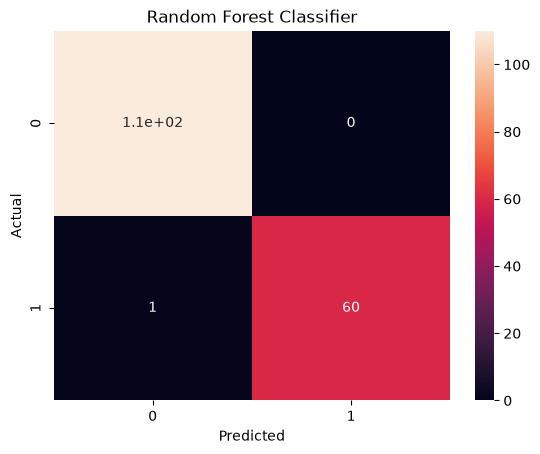

In [ ]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='Random Forest Classifier')

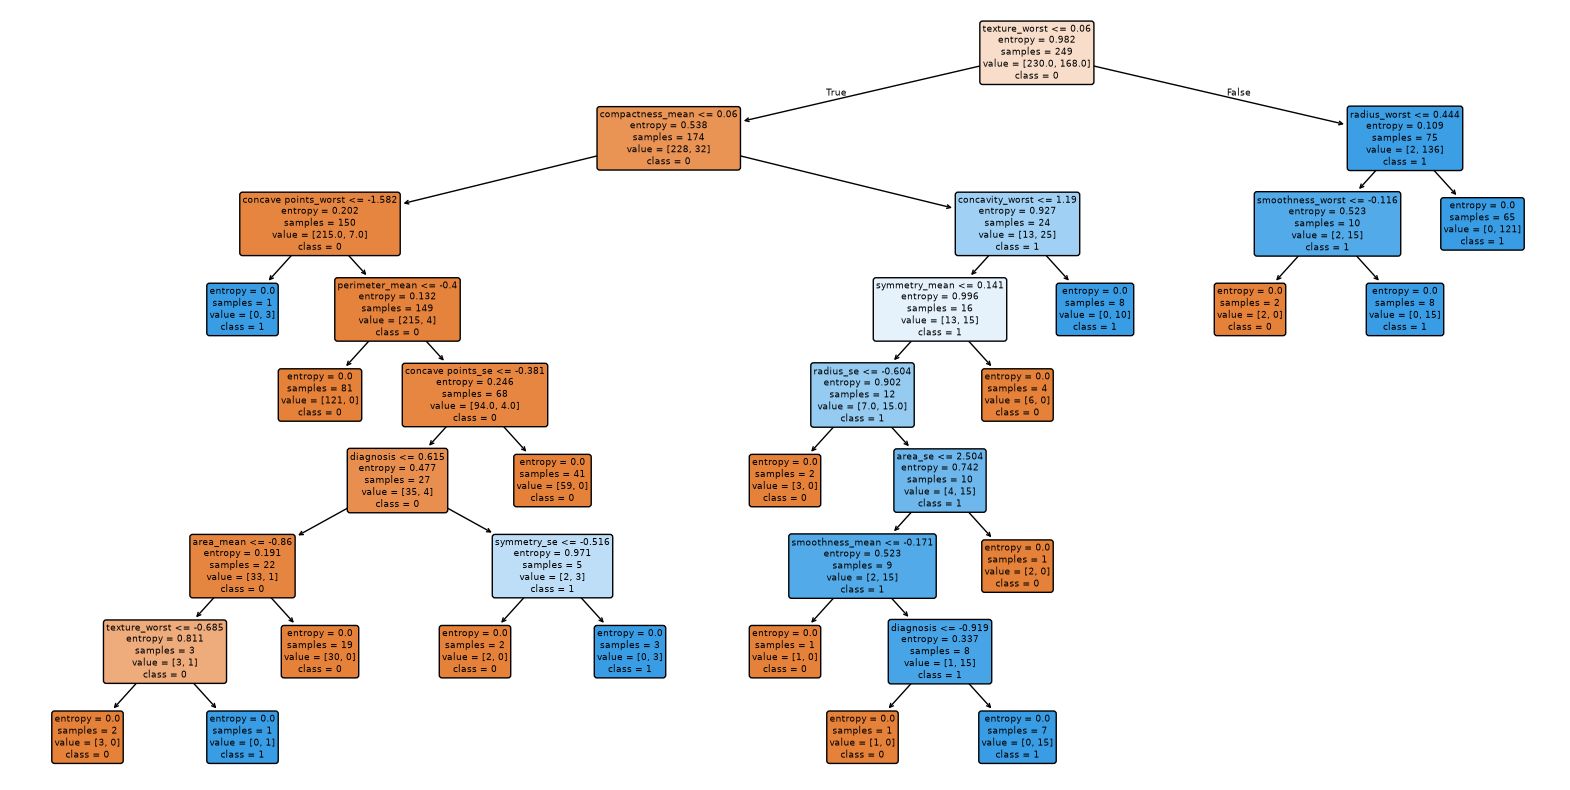

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(model.estimators_[0],
               feature_names=data.columns[:-1],
               class_names=['0', '1'],
               filled=True,
               rounded=True)
plt.show()